<center>
<a href="http://www.insa-toulouse.fr/" ><img src="http://www.math.univ-toulouse.fr/~besse/Wikistat/Images/logo-insa.jpg" style="float:left; max-width: 120px; display: inline" alt="INSA"/></a> 

</center>

# Projet Machine Learning — 4MA 2025-2026
## Prédiction du Risque de Maladie Cardiovasculaire
### INSA Toulouse
---

**Jeu de données** : *Cardiovascular Disease Risk Prediction Dataset* : 15 000 patients   
**Langage** : Python   
**Objectifs** :
- Partie 1 : Prédiction de `Heart_Disease_Risk` 
- Partie 2 : Prédiction de `Cholesterol_LDL` 

> Ce notebook vient compléter l'étude réalisée en R. Les conclusions sont comparables, > mais Python offre une exécution plus rapide, notamment pour la validation croisée.

### 0. Importation des bibliothèques et chargement des données

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

randomseed = 111 

In [60]:
# Suppression des warnings pour une sortie plus propre
import warnings
warnings.filterwarnings("ignore")

In [62]:
df = pd.read_csv("healthcare_synthetic_data.csv")
print(df.shape)
df.head()


(15000, 19)


,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
0,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
1,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
2,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
3,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
4,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0


In [63]:
# Vérification des types de données et des valeurs manquantes
print("Types des variables :")
print(df.dtypes)
print("\nValeurs manquantes :")
print(df.isnull().sum())

# Prétraitement des données
df = df.drop(columns=["Patient_ID"])
for col in ["Gender", "Smoking_Status", "Family_History", "Heart_Disease_Risk"]:
    df[col] = pd.Categorical(df[col], ordered=False)
df["Alcohol_Consumption"] = pd.Categorical(
    df["Alcohol_Consumption"], categories=[0, 1, 2], ordered=True)
df["Physical_Activity_Level"] = pd.Categorical(
    df["Physical_Activity_Level"], categories=[0, 1, 2, 3], ordered=True)
print(df.dtypes)
df.describe()


Types des variables :
Patient_ID                     str
Age                          int64
Gender                       int64
Height_cm                  float64
Weight_kg                  float64
BMI                        float64
Systolic_BP                  int64
Diastolic_BP                 int64
Cholesterol_Total            int64
Cholesterol_LDL              int64
Cholesterol_HDL              int64
Fasting_Blood_Sugar          int64
Smoking_Status               int64
Alcohol_Consumption          int64
Physical_Activity_Level      int64
Family_History               int64
Stress_Level                 int64
Sleep_Hours                  int64
Heart_Disease_Risk           int64
dtype: object

Valeurs manquantes :
Patient_ID                 0
Age                        0
Gender                     0
Height_cm                  0
Weight_kg                  0
BMI                        0
Systolic_BP                0
Diastolic_BP               0
Cholesterol_Total          0
Cholesterol_LDL 

,Age,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Stress_Level,Sleep_Hours
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,54.538133,165.336767,75.252573,27.446080,135.117667,90.541267,216.248000,140.355267,43.307867,99.670200,5.503667,6.506067
std,11.875294,9.186313,14.110559,4.134953,11.260634,8.443095,22.692222,17.914089,5.963153,15.261355,2.874277,1.212626
min,25.000000,138.500000,33.700000,14.500000,90.000000,60.000000,127.000000,70.000000,20.000000,60.000000,1.000000,4.000000
25%,46.000000,158.500000,65.200000,24.500000,127.000000,85.000000,201.000000,128.000000,39.000000,89.000000,3.000000,6.000000
50%,55.000000,164.700000,73.900000,27.200000,135.000000,91.000000,216.000000,140.000000,43.000000,99.000000,5.500000,7.000000
75%,63.000000,172.000000,83.900000,30.000000,143.000000,96.000000,231.000000,152.000000,47.000000,110.000000,8.000000,7.000000
max,85.000000,198.100000,150.100000,46.100000,182.000000,120.000000,303.000000,210.000000,68.000000,167.000000,10.000000,10.000000


### 1. Prédiction du risque d’accident cardiaque

In [64]:
X = df.drop(columns=["Heart_Disease_Risk"])
y = df["Heart_Disease_Risk"]

In [65]:
# Division en ensembles d'apprentissage et de test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=randomseed)

# Vérification des tailles des ensembles
print("Taille apprentissage :", X_train.shape[0])
print("Taille test :", X_test.shape[0])

# Normalisation
scaler = StandardScaler()
scaler.fit(X_train)
Xr_train = scaler.transform(X_train)
Xr_test = scaler.transform(X_test)



Taille apprentissage : 12000
Taille test : 3000


Cette étape est essentielle car elle permet d'estimer les performances réelles du modèle sur des données qu'il n'a jamais vues durant l'apprentissage. Sans cette séparation, le modèle pourrait simplement mémoriser les données d'entraînement et afficher de bonnes performances sans pour autant être capable de généraliser à de nouveaux patients.On retient 20% des données pour le test, soit 3 000 patients.

#### 1.1 Modèle Linéaire Généralisé

##### 1.1.1 Sans pénalisation et sans séléction des variables 

Commentaire pour expliquer que dans ce cas on va pas faire la selection des variables ...

In [66]:
ModelLin = LogisticRegression(random_state=randomseed, max_iter=1000)
ModelLin.fit(Xr_train, y_train)
score = ModelLin.score(Xr_test, y_test)
print("Score du modèle de régression logistique :", score)
y_pred = ModelLin.predict(Xr_test)
print("Matrice de confusion :\n", confusion_matrix(y_test, y_pred))

Score du modèle de régression logistique : 0.753
Matrice de confusion :
 [[1426  335]
 [ 406  833]]


Variables éliminées : 0


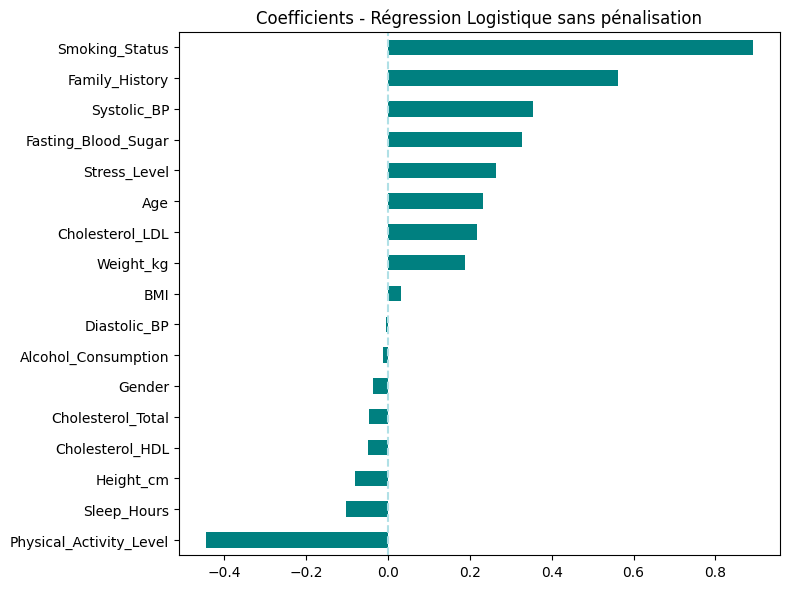

In [67]:
# Visualisation des oefficients
coef = pd.Series(ModelLin.coef_[0], index=X.columns)
print(f"Variables éliminées : {sum(coef == 0)}")
coef.sort_values().plot(kind='barh', figsize=(8,6), color='teal')
plt.title("Coefficients - Régression Logistique sans pénalisation")
plt.axvline(0, color='powderblue', linestyle='--')
plt.tight_layout()
plt.show()

##### 1.1.2 Pénalisation LASSO L1 

In [68]:
from sklearn.model_selection import GridSearchCV

param = [{"C": [0.001,0.01, 0.1, 1, 10, 100]}]
logit = GridSearchCV(LogisticRegression(penalty="l1",solver="liblinear"), param_grid=param, cv=10,n_jobs=-1)
logit0pt=logit.fit(Xr_train, y_train)
logit0pt.best_params_["C"]
print("Meilleur score :",logit0pt.best_score_)
print("Meilleur paramètre C :", logit0pt.best_params_)

yChap = logit0pt.predict(Xr_test)
print("Score du modèle de régression logistique optimisé :", accuracy_score(y_test, yChap))


Meilleur score : 0.7354999999999999
Meilleur paramètre C : {'C': 1}
Score du modèle de régression logistique optimisé : 0.7526666666666667


Variables éliminées : 0


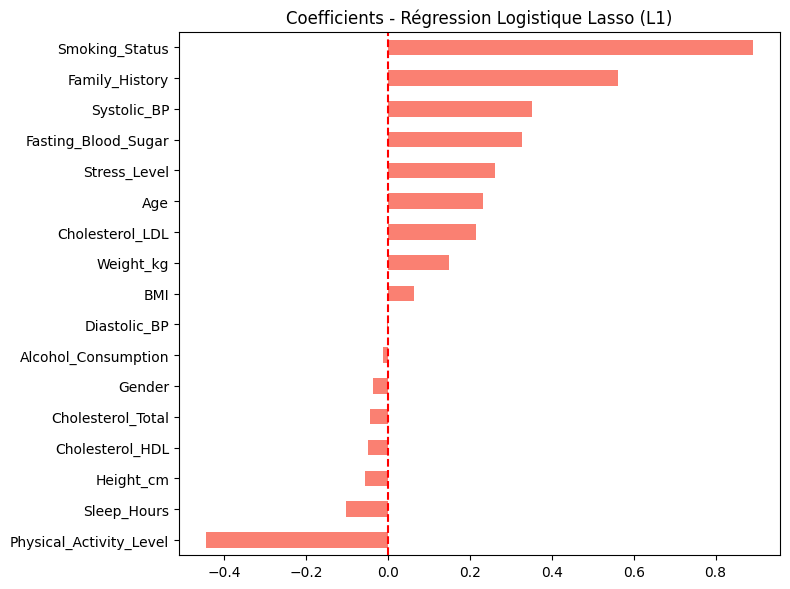

In [69]:
# Visualisation des coefficients
coef_lasso = pd.Series(logit0pt.best_estimator_.coef_[0], index=X.columns)
print(f"Variables éliminées : {sum(coef_lasso == 0)}")
coef_lasso.sort_values().plot(kind='barh', figsize=(8,6), color='salmon')
plt.title("Coefficients - Régression Logistique Lasso (L1)")
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

Avec le C optimal trouvé par validation croisée, le Lasso ne met aucun coefficient à zéro. Les résultats avec pénalisation Lasso (C optimal) sont proches de celles sans pénalisation. Pour un peu pousser l'effet de Lasso sur notre modèle on teste différente valeur de C et voir les variables qui on étés supprimées au bout d'un moment

In [70]:
# Effet de C sur la sélection de variables 
for C in [0.001, 0.01, 0.1, 1, 10, 100]:
    logit_test = LogisticRegression(penalty="l1", solver="liblinear",
                                     C=C, max_iter=1000)
    logit_test.fit(Xr_train, y_train)
    n_zero = sum(logit_test.coef_[0] == 0)
    acc = accuracy_score(y_test, logit_test.predict(Xr_test))
    print(f"C={C:6} | Variables éliminées : {n_zero:2} | Accuracy : {acc:.4f}")

C= 0.001 | Variables éliminées : 14 | Accuracy : 0.7173
C=  0.01 | Variables éliminées :  5 | Accuracy : 0.7510
C=   0.1 | Variables éliminées :  2 | Accuracy : 0.7513
C=     1 | Variables éliminées :  0 | Accuracy : 0.7527
C=    10 | Variables éliminées :  0 | Accuracy : 0.7530
C=   100 | Variables éliminées :  0 | Accuracy : 0.7530
